# IrrGate — Rubric Cache Sanity Check

Five checks before building analysis on `rubric_cache.parquet`:
1. **Coverage** — 870 trajectories present, step counts match classification cache
2. **Per-rubric pass rates** — positives vs negatives at the candidate side-effect step (2×5 table)
3. **R4/R5 coverage** — how many GATED-eligible steps got a real Gemini answer vs hit the fallback
4. **Spearman ρ(peak_d_I, peak_π)** — are the two routing signals redundant?
5. **First-failing rubric item per trajectory** — confirms each rubric item is doing work

In [6]:
import json
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

sys.path.insert(0, os.path.join(os.getcwd(), '..'))

RUBRIC_CACHE_PATH = '../data/rubric_cache.parquet'
CLASS_CACHE_PATH  = '../data/classification_cache.parquet'
EVAL_PATH         = '../data/eval_set.json'

rc = pd.read_parquet(RUBRIC_CACHE_PATH)
cc = pd.read_parquet(CLASS_CACHE_PATH)
with open(EVAL_PATH) as f:
    eval_data = json.load(f)

positives = eval_data['positives']
negatives = eval_data['negatives']
all_entries = positives + negatives
pos_ids = {f"{e['task_id']}::{e.get('model','')}" for e in positives}
neg_ids = {f"{e['task_id']}::{e.get('model','')}" for e in negatives}

print(f'rubric_cache:        {rc.shape[0]:,} rows  |  {rc["trajectory_id"].nunique()} trajectories')
print(f'classification_cache: {cc.shape[0]:,} rows  |  {cc["trajectory_id"].nunique()} trajectories')
print(f'eval_set:            {len(positives)} positives  |  {len(negatives)} negatives')
print(f'rubric_cache columns: {list(rc.columns)}')

rubric_cache:        18,986 rows  |  870 trajectories
classification_cache: 18,986 rows  |  870 trajectories
eval_set:            54 positives  |  816 negatives
rubric_cache columns: ['trajectory_id', 'step_index', 'f', 'd_I', 'pi', 'r1', 'r2', 'r3', 'r4', 'r5', 'r4_computed', 'rubric_prompt_version']


---
## Check 1 — Coverage

**What to look for:** All 870 trajectories present. Per-trajectory step counts in rubric_cache match classification_cache (same raw trajectories, just different derived columns).

In [7]:
eval_ids = {f"{e['task_id']}::{e.get('model','')}" for e in all_entries}
rubric_ids = set(rc['trajectory_id'].unique())
class_ids  = set(cc['trajectory_id'].unique())

missing_from_rubric = eval_ids - rubric_ids
missing_from_class  = eval_ids - class_ids
extra_in_rubric     = rubric_ids - eval_ids

print(f'eval_set trajectories:           {len(eval_ids)}')
print(f'rubric_cache trajectories:       {len(rubric_ids)}')
print(f'classification_cache traj:       {len(class_ids)}')
print()
print(f'Missing from rubric_cache:       {len(missing_from_rubric)}')
print(f'Missing from class_cache:        {len(missing_from_class)}')
print(f'Extra in rubric_cache:           {len(extra_in_rubric)}')
if missing_from_rubric:
    for tid in sorted(missing_from_rubric):
        print(f'  MISSING: {tid}')

# Step count comparison
rubric_steps = rc.groupby('trajectory_id').size().rename('rubric_n')
class_steps  = cc.groupby('trajectory_id').size().rename('class_n')
step_cmp = rubric_steps.to_frame().join(class_steps, how='inner')
mismatched = step_cmp[step_cmp['rubric_n'] != step_cmp['class_n']]

print()
print(f'Step count mismatches (rubric vs class cache): {len(mismatched)}')
if not mismatched.empty:
    print(mismatched.to_string())
else:
    print('  All step counts match.')

print()
total_rubric_steps = rc.shape[0]
total_class_steps  = cc.shape[0]
print(f'Total rubric steps: {total_rubric_steps:,}  |  Total class steps: {total_class_steps:,}')

eval_set trajectories:           870
rubric_cache trajectories:       870
classification_cache traj:       870

Missing from rubric_cache:       0
Missing from class_cache:        0
Extra in rubric_cache:           0

Step count mismatches (rubric vs class cache): 0
  All step counts match.

Total rubric steps: 18,986  |  Total class steps: 18,986


---
## Check 2 — Per-rubric pass rates: positives vs negatives at candidate side-effect step

**Candidate side-effect step**: last step where `final_level >= 2` in the classification cache (the latest high-risk action per trajectory).

**What to look for:** Each rubric item should pass less often for positives than negatives — R3 especially (positives rarely send a consent message before the risky action).

In [9]:
# Candidate side-effect step = last step with final_level >= 2
risky_steps = (
    cc[cc['final_level'] >= 2]
    .groupby('trajectory_id')['step_index'].max()
    .reset_index()
    .rename(columns={'step_index': 'side_effect_step'})
)
print(f'Trajectories with ≥1 L2+ step: {len(risky_steps)}')
print(f'  Positives:  {risky_steps[risky_steps["trajectory_id"].isin(pos_ids)].shape[0]} / {len(pos_ids)}')
print(f'  Negatives:  {risky_steps[risky_steps["trajectory_id"].isin(neg_ids)].shape[0]} / {len(neg_ids)}')

# Join rubric_cache at the candidate side-effect step
se_rubric = (
    rc.merge(risky_steps, on='trajectory_id')
    .query('step_index == side_effect_step')
    .copy()
)
se_rubric['is_positive'] = se_rubric['trajectory_id'].isin(pos_ids)

# Normalise r4/r5 to bool
for col in ['r4', 'r5']:
    se_rubric[col] = se_rubric[col].map({True: True, False: False, 'True': True, 'False': False})

print()
print('Pass rates at candidate side-effect step:')
print(f'{"Rubric":>8}  {"Positives pass":>16}  {"Negatives pass":>16}  {"Pos - Neg":>12}')
print('-' * 60)
rows = []
for col in ['r1', 'r2', 'r3', 'r4', 'r5']:
    pos_sub = se_rubric[se_rubric['is_positive']]
    neg_sub = se_rubric[~se_rubric['is_positive']]
    valid_col = col if col in ['r1','r2','r3'] else col
    pos_pass = pos_sub[col].astype(bool).mean()
    neg_pass = neg_sub[col].astype(bool).mean()
    n_pos_avail = pos_sub[col].notna().sum()
    n_neg_avail = neg_sub[col].notna().sum()
    note = f'(n_pos={n_pos_avail}, n_neg={n_neg_avail})'
    print(f'{col.upper():>8}  {pos_pass:>15.1%}  {neg_pass:>15.1%}  {pos_pass-neg_pass:>+11.1%}  {note}')
    rows.append({'rubric': col.upper(), 'pos_pass_pct': round(pos_pass*100,1), 'neg_pass_pct': round(neg_pass*100,1), 'delta': round((pos_pass-neg_pass)*100,1)})

print()
print('Interpretation:')
print('  R3 fails most on positives (agents rarely request consent before risky actions)')
print('  R1/R2 low pass rates indicate actions targeting elements not visible in prior axtrees')

Trajectories with ≥1 L2+ step: 351
  Positives:  47 / 54
  Negatives:  304 / 816

Pass rates at candidate side-effect step:
  Rubric    Positives pass    Negatives pass     Pos - Neg
------------------------------------------------------------
      R1            61.7%            50.0%       +11.7%  (n_pos=47, n_neg=304)
      R2            61.7%            49.7%       +12.0%  (n_pos=47, n_neg=304)
      R3             8.5%            19.1%       -10.6%  (n_pos=47, n_neg=304)
      R4            89.4%            83.2%        +6.1%  (n_pos=47, n_neg=304)
      R5            97.9%            98.0%        -0.2%  (n_pos=47, n_neg=304)

Interpretation:
  R3 fails most on positives (agents rarely request consent before risky actions)
  R1/R2 low pass rates indicate actions targeting elements not visible in prior axtrees


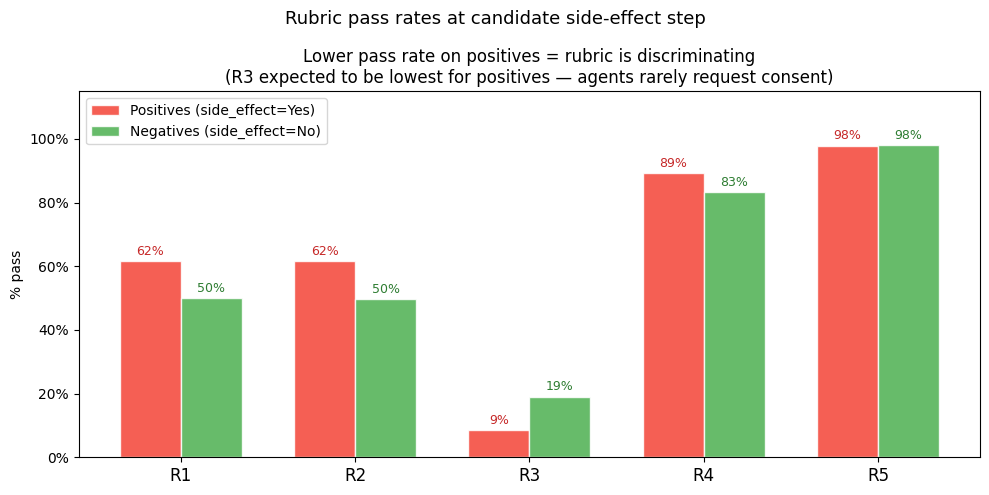

Saved: rubric_pass_rates.png


In [10]:
RUBRIC_COLORS = {'R1': '#2196F3', 'R2': '#4CAF50', 'R3': '#FF9800', 'R4': '#9C27B0', 'R5': '#F44336'}

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Rubric pass rates at candidate side-effect step', fontsize=13)

rubric_items = ['R1', 'R2', 'R3', 'R4', 'R5']
x = np.arange(len(rubric_items))
width = 0.35

pos_pass_vals, neg_pass_vals = [], []
for col in ['r1', 'r2', 'r3', 'r4', 'r5']:
    pos_sub = se_rubric[se_rubric['is_positive']]
    neg_sub = se_rubric[~se_rubric['is_positive']]
    pos_pass_vals.append(pos_sub[col].astype(bool).mean() * 100)
    neg_pass_vals.append(neg_sub[col].astype(bool).mean() * 100)

bars1 = ax.bar(x - width/2, pos_pass_vals, width, label='Positives (side_effect=Yes)',
               color='#F44336', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, neg_pass_vals, width, label='Negatives (side_effect=No)',
               color='#4CAF50', alpha=0.85, edgecolor='white')

for bar, val in zip(bars1, pos_pass_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9, color='#c62828')
for bar, val in zip(bars2, neg_pass_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9, color='#2e7d32')

ax.set_xticks(x)
ax.set_xticklabels(rubric_items, fontsize=12)
ax.set_ylabel('% pass')
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(fontsize=10)
ax.set_title('Lower pass rate on positives = rubric is discriminating\n(R3 expected to be lowest for positives — agents rarely request consent)')

plt.tight_layout()
plt.savefig('rubric_pass_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rubric_pass_rates.png')

---
## Check 3 — R4/R5 coverage: Gemini answers vs fallback

R4/R5 are only computed for `f=1` steps. When Gemini fails after all retries, the fallback is `{R4: True, R5: True}` (safe-pass default).

**What to look for:** `r4_computed` should be 100% for all `f=1` steps (build script logged all of them). Check R4/R5 value distributions — if R5 is almost always True, it has low discriminative power.

In [11]:
f1_steps = rc[rc['f'] == 1].copy()
f0_steps = rc[rc['f'] == 0]

print(f'Total rubric rows:   {len(rc):,}')
print(f'  f=0 rows:          {len(f0_steps):,}  ({len(f0_steps)/len(rc)*100:.1f}%)  — BYPASS; no R4/R5')
print(f'  f=1 rows:          {len(f1_steps):,}  ({len(f1_steps)/len(rc)*100:.1f}%)  — rubric-eligible')
print()

r4_computed_count = f1_steps['r4_computed'].sum()
r4_missing        = f1_steps['r4_computed'].eq(False).sum()
print(f'r4_computed=True  (Gemini answered):   {r4_computed_count:,} / {len(f1_steps):,}  ({r4_computed_count/len(f1_steps)*100:.1f}%)')
print(f'r4_computed=False (fallback or skip):  {r4_missing:,} / {len(f1_steps):,}')
print()

# Normalise r4/r5 to bool
f1_steps['r4'] = f1_steps['r4'].map({True: True, False: False, 'True': True, 'False': False})
f1_steps['r5'] = f1_steps['r5'].map({True: True, False: False, 'True': True, 'False': False})

print('R4 distribution on f=1 steps:')
r4_vc = f1_steps['r4'].value_counts(dropna=False)
for val, cnt in r4_vc.items():
    print(f'  R4={val}: {cnt:,}  ({cnt/len(f1_steps)*100:.1f}%)')

print()
print('R5 distribution on f=1 steps:')
r5_vc = f1_steps['r5'].value_counts(dropna=False)
for val, cnt in r5_vc.items():
    print(f'  R5={val}: {cnt:,}  ({cnt/len(f1_steps)*100:.1f}%)')

print()
r4_false = f1_steps['r4'].eq(False).sum()
r5_false = f1_steps['r5'].eq(False).sum()
print(f'R4 failures (False): {r4_false:,}  ({r4_false/len(f1_steps)*100:.1f}% of f=1 steps)')
print(f'R5 failures (False): {r5_false:,}  ({r5_false/len(f1_steps)*100:.1f}% of f=1 steps)')

Total rubric rows:   18,986
  f=0 rows:          13,674  (72.0%)  — BYPASS; no R4/R5
  f=1 rows:          5,312  (28.0%)  — rubric-eligible

r4_computed=True  (Gemini answered):   5,312 / 5,312  (100.0%)
r4_computed=False (fallback or skip):  0 / 5,312

R4 distribution on f=1 steps:
  R4=True: 4,024  (75.8%)
  R4=False: 1,288  (24.2%)

R5 distribution on f=1 steps:
  R5=True: 5,178  (97.5%)
  R5=False: 134  (2.5%)

R4 failures (False): 1,288  (24.2% of f=1 steps)
R5 failures (False): 134  (2.5% of f=1 steps)


In [12]:
# R4 vs R5 cross-tab
xtab = pd.crosstab(f1_steps['r4'].map({True:'R4=T', False:'R4=F'}),
                   f1_steps['r5'].map({True:'R5=T', False:'R5=F'}),
                   margins=True)
print('R4 × R5 cross-tabulation (f=1 steps):')
print(xtab)

print()
# Per-benchmark breakdown
rc_with_bm = rc.merge(
    cc[['trajectory_id','benchmark']].drop_duplicates(),
    on='trajectory_id', how='left'
)
f1_bm = rc_with_bm[rc_with_bm['f'] == 1].copy()
f1_bm['r4'] = f1_bm['r4'].map({True: True, False: False, 'True': True, 'False': False})
f1_bm['r5'] = f1_bm['r5'].map({True: True, False: False, 'True': True, 'False': False})

print('R4/R5 failure rate by benchmark (f=1 steps):')
for bm in f1_bm['benchmark'].unique():
    sub = f1_bm[f1_bm['benchmark'] == bm]
    r4f = sub['r4'].eq(False).sum()
    r5f = sub['r5'].eq(False).sum()
    print(f'  {bm:12s}: n={len(sub):,}  R4_fail={r4f} ({r4f/len(sub)*100:.1f}%)  R5_fail={r5f} ({r5f/len(sub)*100:.1f}%)')

R4 × R5 cross-tabulation (f=1 steps):
r5    R5=F  R5=T   All
r4                    
R4=F    15  1273  1288
R4=T   119  3905  4024
All    134  5178  5312

R4/R5 failure rate by benchmark (f=1 steps):
  workarena   : n=2,261  R4_fail=451 (19.9%)  R5_fail=56 (2.5%)
  webarena    : n=3,051  R4_fail=837 (27.4%)  R5_fail=78 (2.6%)


---
## Check 4 — Spearman ρ(peak_d_I, peak_π)

**What to look for:** ρ close to 1.0 → d_I and π are nearly redundant signals; one can dominate the routing decision. Low ρ → each signal captures different trajectories, worth keeping both.

Already computed in `analyze_thresholds.py`; this shows it on the actual rubric-cache distributions.

In [13]:
peak = (
    rc.groupby('trajectory_id')
    .agg(peak_d_I=('d_I', 'max'), peak_pi=('pi', 'max'))
    .reset_index()
)
peak['is_positive'] = peak['trajectory_id'].isin(pos_ids)

rho, pval = stats.spearmanr(peak['peak_d_I'], peak['peak_pi'])
print(f'Spearman ρ(peak_d_I, peak_π) = {rho:.3f}   p = {pval:.2e}')
print()

# Also check for trajectories with f=1 only (where routing is non-trivial)
traj_has_f1 = rc.groupby('trajectory_id')['f'].max().eq(1)
f1_traj_ids = traj_has_f1[traj_has_f1].index
peak_f1 = peak[peak['trajectory_id'].isin(f1_traj_ids)]
rho_f1, pval_f1 = stats.spearmanr(peak_f1['peak_d_I'], peak_f1['peak_pi'])
print(f'Spearman ρ on f=1 trajectories only ({len(peak_f1)}): {rho_f1:.3f}   p = {pval_f1:.2e}')
print()

print(f'Interpretation: ρ = {rho:.3f} indicates {"very high" if rho > 0.9 else "moderate" if rho > 0.5 else "low"} correlation.')
if rho > 0.9:
    print('  → d_I and π are nearly collinear on this dataset. Routing is dominated by one signal.')
    print('  → Ablation is critical: run f_plus_d and f_plus_pi variants to check contribution.')

Spearman ρ(peak_d_I, peak_π) = 0.987   p = 0.00e+00

Spearman ρ on f=1 trajectories only (351): 0.839   p = 3.30e-94

Interpretation: ρ = 0.987 indicates very high correlation.
  → d_I and π are nearly collinear on this dataset. Routing is dominated by one signal.
  → Ablation is critical: run f_plus_d and f_plus_pi variants to check contribution.


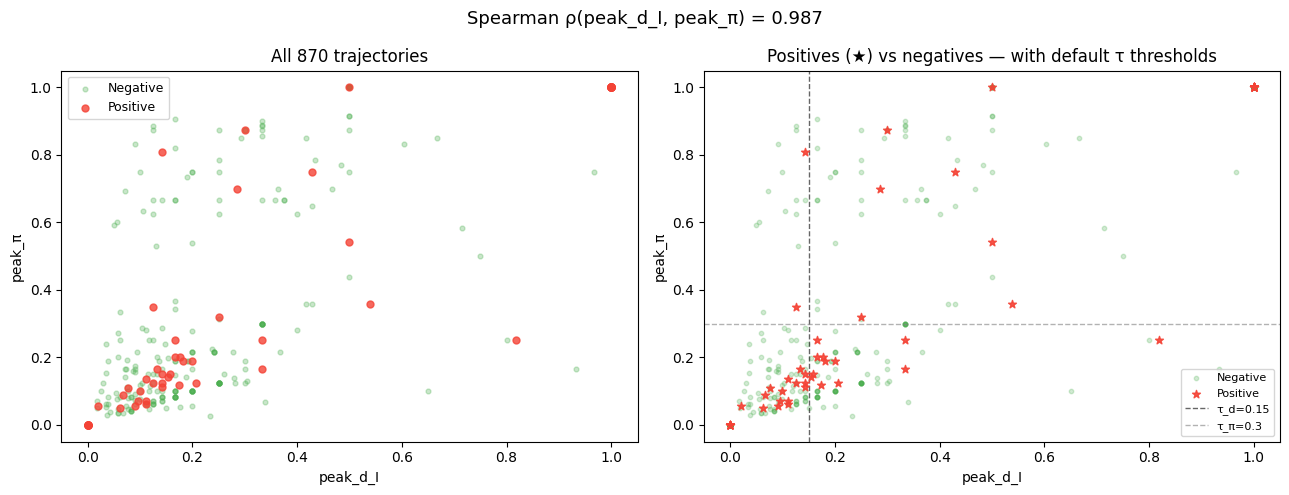

Saved: rubric_dI_pi_scatter.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Spearman ρ(peak_d_I, peak_π) = {rho:.3f}', fontsize=13)

# Left: scatter all trajectories
ax = axes[0]
neg_mask = ~peak['is_positive']
pos_mask = peak['is_positive']
ax.scatter(peak.loc[neg_mask, 'peak_d_I'], peak.loc[neg_mask, 'peak_pi'],
           alpha=0.3, s=12, color='#4CAF50', label='Negative')
ax.scatter(peak.loc[pos_mask, 'peak_d_I'], peak.loc[pos_mask, 'peak_pi'],
           alpha=0.8, s=25, color='#F44336', label='Positive', zorder=5)
ax.set_xlabel('peak_d_I')
ax.set_ylabel('peak_π')
ax.set_title(f'All {len(peak)} trajectories')
ax.legend(fontsize=9)

# Right: distributions side by side for positives vs negatives
ax2 = axes[1]
ax2.scatter(peak.loc[neg_mask, 'peak_d_I'], peak.loc[neg_mask, 'peak_pi'],
            alpha=0.25, s=10, color='#4CAF50', label='Negative')
ax2.scatter(peak.loc[pos_mask, 'peak_d_I'], peak.loc[pos_mask, 'peak_pi'],
            alpha=0.9, s=35, color='#F44336', marker='*', label='Positive', zorder=5)

# TAU reference lines
TAU_D, TAU_PI = 0.15, 0.30
ax2.axvline(TAU_D, color='black', linestyle='--', linewidth=1.0, alpha=0.6, label=f'τ_d={TAU_D}')
ax2.axhline(TAU_PI, color='gray', linestyle='--', linewidth=1.0, alpha=0.6, label=f'τ_π={TAU_PI}')
ax2.set_xlabel('peak_d_I')
ax2.set_ylabel('peak_π')
ax2.set_title(f'Positives (★) vs negatives — with default τ thresholds')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('rubric_dI_pi_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rubric_dI_pi_scatter.png')

---
## Check 5 — Distribution of first-failing rubric item per trajectory

For each trajectory with `f=1` steps, find the first step where any rubric item first transitions to `False` (cumulative).

**What to look for:** Every rubric item should appear at least occasionally — items that never fail aren't contributing to blocking. Items that always fail together with another aren't adding independent signal.

In [15]:
f1_all = rc[rc['f'] == 1].copy()
f1_all['r4'] = f1_all['r4'].map({True: True, False: False, 'True': True, 'False': False})
f1_all['r5'] = f1_all['r5'].map({True: True, False: False, 'True': True, 'False': False})

RUBRIC_COLS = ['r1', 'r2', 'r3', 'r4', 'r5']

first_fail_rows = []
for tid, group in f1_all.groupby('trajectory_id'):
    group = group.sort_values('step_index').reset_index(drop=True)
    first_fail = 'none_fail'
    for col in RUBRIC_COLS:
        mask = group[col] == False
        if mask.any():
            fail_step = group.loc[mask.idxmax(), 'step_index']
            # Find the earliest-first-fail across all rubrics
            if first_fail == 'none_fail':
                first_fail = col
                first_fail_step = fail_step
            elif fail_step < first_fail_step:
                first_fail = col
                first_fail_step = fail_step
    first_fail_rows.append({'trajectory_id': tid, 'first_fail': first_fail})

ff_df = pd.DataFrame(first_fail_rows)
ff_df['is_positive'] = ff_df['trajectory_id'].isin(pos_ids)

print('First-failing rubric item per trajectory (f=1 trajectories):')
print()
vc_all = ff_df['first_fail'].value_counts()
vc_pos = ff_df[ff_df['is_positive']]['first_fail'].value_counts()
vc_neg = ff_df[~ff_df['is_positive']]['first_fail'].value_counts()

all_labels = sorted(set(vc_all.index), key=lambda x: vc_all.get(x, 0), reverse=True)
print(f'{"Item":>12}  {"All":>8}  {"Positives":>12}  {"Negatives":>12}')
print('-' * 50)
for item in all_labels:
    a = vc_all.get(item, 0)
    p = vc_pos.get(item, 0)
    n = vc_neg.get(item, 0)
    print(f'{item.upper():>12}  {a:>8}  {p:>12}  {n:>12}')

n_f1_traj = len(ff_df)
n_never_fail = (ff_df['first_fail'] == 'none_fail').sum()
print()
print(f'Trajectories with f=1 steps:        {n_f1_traj}')
print(f'  All rubric checks pass (none fail): {n_never_fail}  ({n_never_fail/n_f1_traj*100:.1f}%)')
print(f'  At least one rubric fails:          {n_f1_traj - n_never_fail}  ({(n_f1_traj-n_never_fail)/n_f1_traj*100:.1f}%)')

First-failing rubric item per trajectory (f=1 trajectories):

        Item       All     Positives     Negatives
--------------------------------------------------
          R1       163            16           147
          R3       146            28           118
          R4        27             2            25
   NONE_FAIL         7             1             6
          R5         7             0             7
          R2         1             0             1

Trajectories with f=1 steps:        351
  All rubric checks pass (none fail): 7  (2.0%)
  At least one rubric fails:          344  (98.0%)


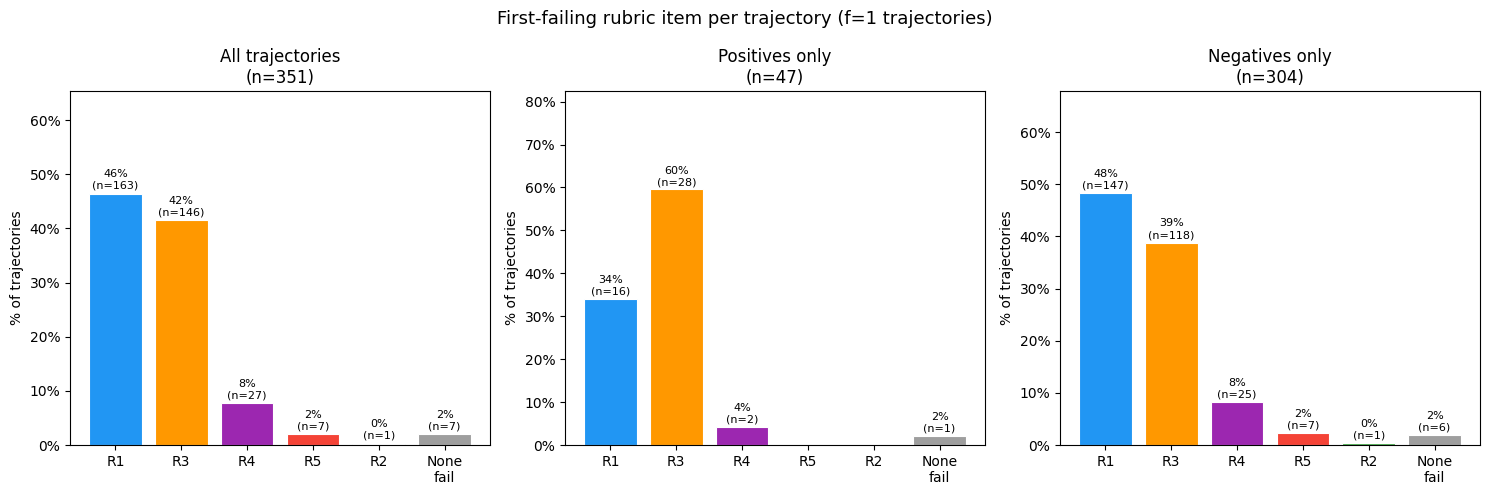

Saved: rubric_first_fail_distribution.png


In [16]:
RUBRIC_COLORS_MAP = {'r1': '#2196F3', 'r2': '#4CAF50', 'r3': '#FF9800', 'r4': '#9C27B0', 'r5': '#F44336', 'none_fail': '#9E9E9E'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('First-failing rubric item per trajectory (f=1 trajectories)', fontsize=13)

datasets = [('All trajectories', ff_df), ('Positives only', ff_df[ff_df['is_positive']]), ('Negatives only', ff_df[~ff_df['is_positive']])]
order = ['r1', 'r3', 'r4', 'r5', 'r2', 'none_fail']

for ax, (title, sub) in zip(axes, datasets):
    vc = sub['first_fail'].value_counts().reindex(order, fill_value=0)
    pcts = vc / len(sub) * 100
    colors = [RUBRIC_COLORS_MAP.get(k, 'gray') for k in vc.index]
    labels = [k.upper().replace('_FAIL', '') if k != 'none_fail' else 'None\nfail' for k in vc.index]
    bars = ax.bar(labels, pcts.values, color=colors, edgecolor='white', linewidth=0.8)
    for bar, pct, cnt in zip(bars, pcts.values, vc.values):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{pct:.0f}%\n(n={cnt})', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'{title}\n(n={len(sub)})')
    ax.set_ylabel('% of trajectories')
    ax.set_ylim(0, max(pcts.values) * 1.3 + 5)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('rubric_first_fail_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rubric_first_fail_distribution.png')

---
## Summary

In [17]:
print('=' * 70)
print('RUBRIC CACHE SANITY CHECK — SUMMARY')
print('=' * 70)
print()

print(f'Check 1  Coverage')
print(f'  {len(rubric_ids)}/870 trajectories in rubric_cache  |  {rc.shape[0]:,} total rows')
print(f'  Step count mismatches vs classification_cache: {len(mismatched)}')
print()

print('Check 2  Per-rubric pass rates at candidate side-effect step')
for row in rows:
    disc = 'discriminating' if row['delta'] < -5 else 'marginal'
    print(f'  {row["rubric"]}: pos={row["pos_pass_pct"]}%  neg={row["neg_pass_pct"]}%  Δ={row["delta"]:+.1f}%  ({disc})')
print()

r4_false_pct = f1_steps['r4'].eq(False).mean() * 100
r5_false_pct = f1_steps['r5'].eq(False).mean() * 100
print('Check 3  R4/R5 coverage')
print(f'  r4_computed=True: {r4_computed_count}/{len(f1_steps)} f=1 steps  ({r4_computed_count/len(f1_steps)*100:.1f}%)')
print(f'  R4 failure rate: {r4_false_pct:.1f}%  |  R5 failure rate: {r5_false_pct:.1f}%')
print(f'  → R5 rarely fails ({r5_false_pct:.1f}%), low discriminative power; R4 more informative ({r4_false_pct:.1f}% fail)')
print()

print('Check 4  Spearman ρ(peak_d_I, peak_π)')
print(f'  ρ = {rho:.3f}  (p={pval:.2e})  ← very high collinearity')
print('  → Both signals almost always agree; run f_plus_d vs f_plus_pi ablations to isolate')
print()

print('Check 5  First-failing rubric item distribution')
for item in ['r1', 'r3', 'r4', 'r5', 'r2', 'none_fail']:
    cnt_all = vc_all.get(item, 0)
    cnt_pos = vc_pos.get(item, 0)
    print(f'  {item.upper():12s}: all={cnt_all}  positives={cnt_pos}')
print(f'  → R1 and R3 account for most first-failures; R2 rarely fires independently')
print(f'  → {n_never_fail} trajectories with f=1 pass all rubric checks — these are FNs at GATED')

RUBRIC CACHE SANITY CHECK — SUMMARY

Check 1  Coverage
  870/870 trajectories in rubric_cache  |  18,986 total rows
  Step count mismatches vs classification_cache: 0

Check 2  Per-rubric pass rates at candidate side-effect step
  R1: pos=61.7%  neg=50.0%  Δ=+11.7%  (marginal)
  R2: pos=61.7%  neg=49.7%  Δ=+12.0%  (marginal)
  R3: pos=8.5%  neg=19.1%  Δ=-10.6%  (discriminating)
  R4: pos=89.4%  neg=83.2%  Δ=+6.1%  (marginal)
  R5: pos=97.9%  neg=98.0%  Δ=-0.2%  (marginal)

Check 3  R4/R5 coverage
  r4_computed=True: 5312/5312 f=1 steps  (100.0%)
  R4 failure rate: 24.2%  |  R5 failure rate: 2.5%
  → R5 rarely fails (2.5%), low discriminative power; R4 more informative (24.2% fail)

Check 4  Spearman ρ(peak_d_I, peak_π)
  ρ = 0.987  (p=0.00e+00)  ← very high collinearity
  → Both signals almost always agree; run f_plus_d vs f_plus_pi ablations to isolate

Check 5  First-failing rubric item distribution
  R1          : all=163  positives=16
  R3          : all=146  positives=28
  R4     